### MasterCard Stock Price Prediction Using LSTM & GRU
we are going to use Kaggle’s MasterCard stock dataset from May-25-2006 to Oct-11-2021 and train the LSTM and GRU models to forecast the stock price. This is a project where we will analyze data, preprocess the data to train it on advanced RNN models, and finally evaluate the results.

data grathering

In [2]:
import yfinance as yf
import os

def download_stock_data(ticker="MA", start="2010-01-01", end=None, save_path="data/Mastercard_stock_history.csv"):
    """Download historical stock data and save it in the format your notebook expects."""
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    stock = yf.Ticker(ticker)
    df = stock.history(start=start, end=end, actions=True)  # actions=True includes Dividends & Stock Splits
    
    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker}' — check the symbol or date range.")
    
    df.index.name = "Date"
    df.to_csv(save_path)
    print(f"Saved {len(df)} rows to {save_path}")
    return df

# Usage:
dataset = download_stock_data()

Saved 4160 rows to data/Mastercard_stock_history.csv


step 1 - libraby installation

In [3]:
import numpy as  np #numpy and pandas are used for data manipulation and analysis.
import pandas as pd #matplotlib is used for data visualization.
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler #MinMaxScaler and mean_squared_error are used for data preprocessing and evaluation respectively.
from sklearn.metrics import mean_squared_error

# Sequential, Dense, LSTM, Dropout, GRU, Bidirectional, and SGD are all classes from the tensorflow.keras module, which is used for building and training deep learning models.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.optimizers import SGD
from tensorflow.random import set_seed

set_seed(455)
np.random.seed(455)

Step 2 - data analysis 

In [4]:
dataset = pd.read_csv(
    "data/Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"]
).drop(["Dividends", "Stock Splits"], axis=1)
print(dataset.head())

                                Open       High        Low      Close  \
Date                                                                    
2010-01-04 00:00:00-05:00  23.607936  23.627152  23.432242  23.502703   
2010-01-05 00:00:00-05:00  23.594212  23.605192  23.155893  23.433159   
2010-01-06 00:00:00-05:00  23.461535  23.461535  23.119097  23.399273   
2010-01-07 00:00:00-05:00  23.201510  23.261940  22.979932  23.246374   
2010-01-08 00:00:00-05:00  23.103536  23.340679  23.045853  23.254612   

                             Volume  
Date                                 
2010-01-04 00:00:00-05:00   9321000  
2010-01-05 00:00:00-05:00  12906000  
2010-01-06 00:00:00-05:00  10785000  
2010-01-07 00:00:00-05:00  11273000  
2010-01-08 00:00:00-05:00   8635000  


In [5]:
print(dataset.describe())

              Open         High          Low        Close        Volume
count  4160.000000  4160.000000  4160.000000  4160.000000  4.160000e+03
mean    217.467406   219.564479   215.355953   217.516161  5.418094e+06
std     171.865171   173.464267   170.283279   171.907676  5.682759e+06
min      17.670034    18.034011    17.511419    17.601269  6.411000e+05
25%      69.145463    69.777129    68.621102    69.084274  2.725650e+06
50%     170.031231   171.364557   167.603673   169.797729  3.808650e+06
75%     349.515400   353.704533   346.002247   349.665077  6.054100e+06
max     594.117690   598.043267   589.407081   595.250671  1.083800e+08


In [6]:
dataset.isna().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

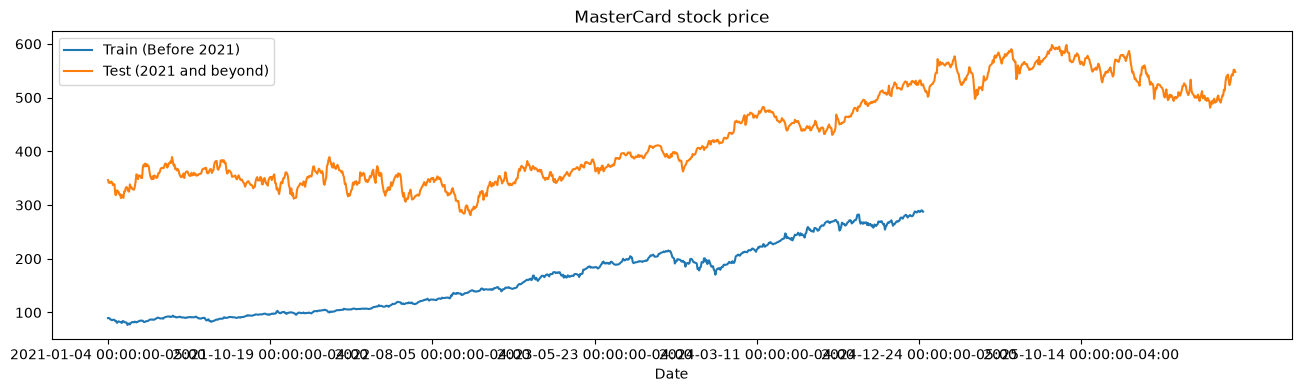

In [7]:
tstart = 2016
tend = 2020

def train_test_plot(dataset, tstart, tend):
    dataset.loc[f"{tstart}":f"{tend}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{tend+1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Before {tend+1})", f"Test ({tend+1} and beyond)"])
    plt.title("MasterCard stock price")
    plt.show()

train_test_plot(dataset,tstart,tend)

Step 3 - data preprocessing

In [8]:
def train_test_split(dataset, tstart, tend):
    train = dataset.loc[f"{tstart}":f"{tend}", "High"].values
    test = dataset.loc[f"{tend+1}":, "High"].values
    return train, test
training_set, test_set = train_test_split(dataset, tstart, tend)



In [9]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)



In [10]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


n_steps = 60
features = 1
# split into samples
X_train, y_train = split_sequence(training_set_scaled, n_steps)



In [11]:

# The LSTM architecture
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, activation="tanh", input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))
# Compiling the model
model_lstm.compile(optimizer="RMSprop", loss="mse")

model_lstm.summary()
Model: "sequential"

/Users/ashwinbhagat/projects/Deep_learning/RNN_stock_prediction/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0250
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0030
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0016
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0013
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012  
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011  
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.6551e-04
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.8826e-04
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.2486e-04
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.7202e-04
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.2740e-04
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.8923e-04
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

In [13]:
dataset_total = dataset.loc[:,"High"]
inputs = dataset_total[len(dataset_total) - len(test_set) - n_steps :].values
inputs = inputs.reshape(-1, 1)
#scaling
inputs = sc.transform(inputs)

# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)
#prediction
predicted_stock_price = model_lstm.predict(X_test)
#inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [14]:
def plot_predictions(test, predicted):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard Stock Price")
    plt.legend()
    plt.show()


def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))


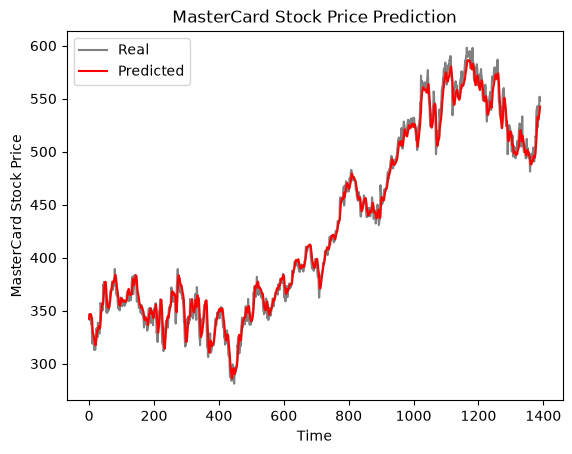

In [18]:
plot_predictions(test_set ,predicted_stock_price)




In [19]:
return_rmse(test_set,predicted_stock_price)

The root mean squared error is 8.33.
